# Diffusion rollout degradation by topology

This notebook discovers ring and grid diffusion JSONL logs, aggregates repeated seeds into mean MSE curves with standard-error halos, and exports a separate continued-drive / drive-cutoff figure for each topology. Step 0 is shown on the axis as the observed starting point; no prediction is scored at step 0.

In [13]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

font_manager.fontManager = font_manager._load_fontmanager(try_read_cache=False)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
PAPER_FONT = next((name for name in ("Source Sans 3", "Source Sans Pro", "Nimbus Sans", "Ubuntu Sans", "Liberation Sans", "DejaVu Sans") if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [PAPER_FONT],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})
print(f"Publication font: {PAPER_FONT}")


Publication font: Source Sans Pro


In [ ]:
JSONL_PATH = Path("..") / "derived" / "results" / "first_order_diffusion_ring_seed0_cutoff5.jsonl"
TARGET_BLOCK = "rollout_test"
INTERVENTION_BLOCK = "rollout_intervention_test"
METRIC = "edge_mse"
MAX_STEP = 20
EXPORT_STEM = Path("..") / "derived" / "figures" / "diffusion_rollout_by_model"

with JSONL_PATH.open(encoding="utf-8") as handle:
    rows = [json.loads(line) for line in handle if line.strip()]

if not rows:
    raise ValueError(f"No JSONL records found in {JSONL_PATH}")

# Keep the latest epoch that actually contains per-step rollout metrics.
# This is robust to JSONL files that contain appended runs with different horizons.
final_rows = {}
for row in rows:
    run = row.get("run", "unknown")
    step_block = row.get(TARGET_BLOCK, {}).get("rollout_by_step", {})
    if not step_block:
        continue
    if run not in final_rows or row.get("epoch", -1) >= final_rows[run].get("epoch", -1):
        final_rows[run] = row

# Intervention runs may have been appended with fewer epochs than the
# ordinary run. Select their final epoch independently.
final_intervention_rows = {}
for row in rows:
    run = row.get("run", "unknown")
    step_block = row.get(INTERVENTION_BLOCK, {}).get("rollout_by_step", {})
    if not step_block:
        continue
    if run not in final_intervention_rows or row.get("epoch", -1) >= final_intervention_rows[run].get("epoch", -1):
        final_intervention_rows[run] = row

# This figure compares the generic first-order FNN with non-IFT baselines.
DISPLAY_RUNS = {"ift1_generic"}
curves = {}
intervention_curves = {}
persistence_curves = []
intervention_persistence_curves = []
missing = []
for run, row in final_rows.items():
    step_block = row.get(TARGET_BLOCK, {}).get("rollout_by_step", {})
    if not step_block:
        missing.append(run)
        continue
    if run.startswith("ift") and run not in DISPLAY_RUNS:
        continue
    curves[run] = {int(step): values.get(METRIC) for step, values in step_block.items() if int(step) <= MAX_STEP}
    persistent_block = row.get(TARGET_BLOCK, {}).get("rollout_persistent_by_step", {})
    if persistent_block:
        persistence_curves.append({int(step): values.get(METRIC) for step, values in persistent_block.items() if int(step) <= MAX_STEP})
    print(f"{run}: selected epoch {row.get('epoch')} with {len(curves[run])} rollout steps")

for run, row in final_intervention_rows.items():
    if run.startswith("ift") and run not in DISPLAY_RUNS:
        continue
    intervention_block = row[INTERVENTION_BLOCK]["rollout_by_step"]
    intervention_curves[run] = {int(step): values.get(METRIC) for step, values in intervention_block.items() if int(step) <= MAX_STEP}
    intervention_persistent_block = row[INTERVENTION_BLOCK].get("rollout_persistent_by_step", {})
    if intervention_persistent_block:
        intervention_persistence_curves.append({int(step): values.get(METRIC) for step, values in intervention_persistent_block.items() if int(step) <= MAX_STEP})
    print(f"{run}: selected intervention epoch {row.get('epoch')} with {len(intervention_curves[run])} rollout steps")

if missing:
    print("No per-step rollout metrics for:", ", ".join(missing))
if not curves:
    raise ValueError(
        "This file contains no per-step rollout metrics. Its evaluation split is likely shorter than the requested horizon. "
        "Regenerate with more --num-bins (for example 192) or a smaller --rollout-horizon."
    )

# Persistence is data-defined, so it should agree across models. Average available copies defensively.
persistence_curve = {}
intervention_persistence_curve = {}
for step in range(1, MAX_STEP + 1):
    values = [curve[step] for curve in persistence_curves if step in curve and curve[step] is not None]
    if values:
        persistence_curve[step] = sum(values) / len(values)
    intervention_values = [curve[step] for curve in intervention_persistence_curves if step in curve and curve[step] is not None]
    if intervention_values:
        intervention_persistence_curve[step] = sum(intervention_values) / len(intervention_values)

print(f"Loaded {len(curves)} model curves from final epoch records.")
print(f"Persistence baseline: {len(persistence_curve)} rollout steps.")
print(f"Loaded {len(intervention_curves)} drive-cutoff curves; cutoff is after step 5.")

# Aggregate all matching topology/seed files independently. A file may contain
# multiple epochs and appended experiments, so selection is repeated within
# each metric block for each seed.
RESULTS_DIR = Path("..") / "derived" / "results"
EXPORT_DIR = Path("..") / "derived" / "figures"
TOPOLOGIES = ("ring", "grid", "torus", "doorway", "swiss_cheese")

def select_final_rows(rows, block_name):
    selected = {}
    for row in rows:
        run = row.get("run", "unknown")
        if not row.get(block_name, {}).get("rollout_by_step", {}):
            continue
        if run not in selected or row.get("epoch", -1) >= selected[run].get("epoch", -1):
            selected[run] = row
    return selected

def keep_display_run(run):
    return not run.startswith("ift") or run == "ift1_generic"

topology_data = {
    topology: {"continued": {}, "cutoff": {}, "continued_persistence": {}, "cutoff_persistence": {}}
    for topology in TOPOLOGIES
}
for topology in TOPOLOGIES:
    for path in sorted(RESULTS_DIR.glob(f"first_order_diffusion_{topology}_seed*_cutoff5.jsonl")):
        seed = path.stem.split("_seed", 1)[1].split("_", 1)[0]
        with path.open(encoding="utf-8") as handle:
            seed_rows = [json.loads(line) for line in handle if line.strip()]
        for condition, block_name in (("continued", TARGET_BLOCK), ("cutoff", INTERVENTION_BLOCK)):
            selected = select_final_rows(seed_rows, block_name)
            for run, row in selected.items():
                if not keep_display_run(run):
                    continue
                step_block = row[block_name]["rollout_by_step"]
                topology_data[topology][condition].setdefault(run, {})[seed] = {
                    int(step): values[METRIC] for step, values in step_block.items() if int(step) <= MAX_STEP
                }
            if selected:
                reference = next(iter(selected.values()))
                persistent_block = reference[block_name].get("rollout_persistent_by_step", {})
                topology_data[topology][f"{condition}_persistence"][seed] = {
                    int(step): values[METRIC] for step, values in persistent_block.items() if int(step) <= MAX_STEP
                }
        print(f"{topology}: loaded seed {seed} from {path.name}")

for topology in TOPOLOGIES:
    print(
        f"{topology}: continued models={len(topology_data[topology]['continued'])}, "
        f"cutoff models={len(topology_data[topology]['cutoff'])}, "
        f"seeds={sorted(topology_data[topology]['continued_persistence'])}"
    )


ift1_generic: selected epoch 3 with 20 rollout steps
sum/tgn_gru: selected epoch 3 with 20 rollout steps
deepsets/tgn_gru: selected epoch 3 with 20 rollout steps
settransformer/tgn_gru: selected epoch 3 with 20 rollout steps
hopfield/hopfield_update: selected epoch 3 with 20 rollout steps
settransformer/lnn: selected epoch 3 with 20 rollout steps
settransformer/hnn: selected epoch 3 with 20 rollout steps
ift1_generic: selected intervention epoch 3 with 20 rollout steps
sum/tgn_gru: selected intervention epoch 3 with 20 rollout steps
deepsets/tgn_gru: selected intervention epoch 3 with 20 rollout steps
settransformer/tgn_gru: selected intervention epoch 3 with 20 rollout steps
hopfield/hopfield_update: selected intervention epoch 3 with 20 rollout steps
settransformer/lnn: selected intervention epoch 3 with 20 rollout steps
settransformer/hnn: selected intervention epoch 3 with 20 rollout steps
Loaded 7 model curves from final epoch records.
Persistence baseline: 20 rollout steps.
Loade

Saved ../derived/figures/diffusion_ring_rollout_by_model.pdf and ../derived/figures/diffusion_ring_rollout_by_model.png


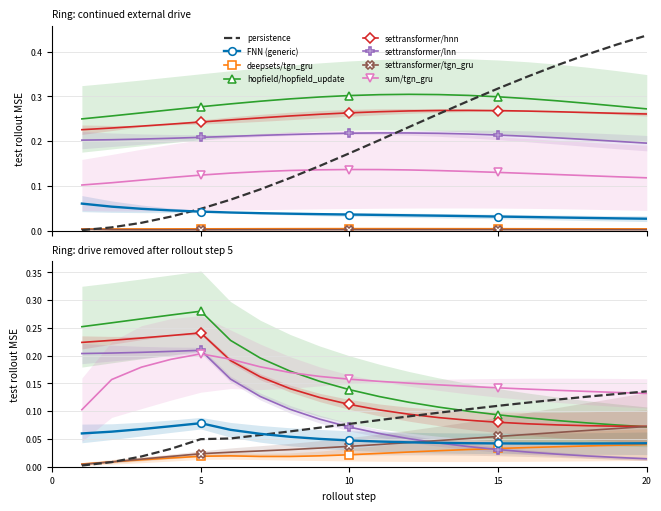

Saved ../derived/figures/diffusion_grid_rollout_by_model.pdf and ../derived/figures/diffusion_grid_rollout_by_model.png


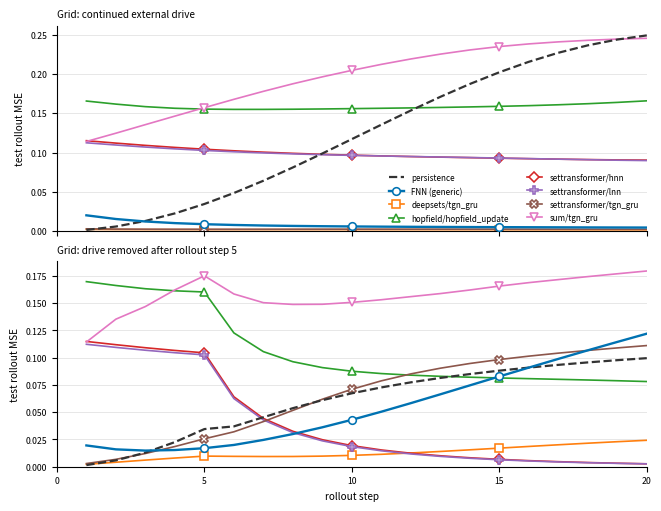

In [15]:
IFT_STYLES = {
    "ift1_generic": {"label": "FNN (generic)", "color": "#0072B2", "linestyle": "-"},
}
BASELINE_COLORS = plt.get_cmap("tab10").colors
MODEL_MARKERS = ("o", "s", "^", "D", "P", "X", "v", "h")
MARKER_STEPS = (5, 10, 15)

def aggregate_seed_curves(seed_curves):
    steps = sorted({step for curve in seed_curves.values() for step in curve})
    mean, lower, upper = [], [], []
    for step in steps:
        values = [curve[step] for curve in seed_curves.values() if step in curve]
        center = sum(values) / len(values)
        sem = 0.0 if len(values) < 2 else (sum((value - center) ** 2 for value in values) / (len(values) - 1)) ** 0.5 / len(values) ** 0.5
        mean.append(center)
        lower.append(center - sem)
        upper.append(center + sem)
    return steps, mean, lower, upper, len(seed_curves)

def plot_panel(axis, panel_curves, persistence_by_seed, title, *, show_legend=False):
    if persistence_by_seed:
        steps, mean, _, _, _ = aggregate_seed_curves(persistence_by_seed)
        axis.plot(steps, mean, label="persistence", color="0.2", linewidth=1.6, linestyle="--", zorder=3)
    ift_runs = [(run, panel_curves[run]) for run in IFT_STYLES if run in panel_curves]
    baseline_runs = sorted((run, values) for run, values in panel_curves.items() if run not in IFT_STYLES)
    for index, (run, seed_curves) in enumerate([*ift_runs, *baseline_runs]):
        style = IFT_STYLES.get(run)
        color = style["color"] if style else BASELINE_COLORS[index % len(BASELINE_COLORS)]
        steps, mean, lower, upper, n_seeds = aggregate_seed_curves(seed_curves)
        marker_indices = [steps.index(step) for step in MARKER_STEPS if step in steps]
        axis.fill_between(steps, lower, upper, color=color, alpha=0.16, linewidth=0, zorder=1)
        axis.plot(steps, mean, label=style["label"] if style else run, linewidth=1.7 if style else 1.2, color=color, linestyle=style["linestyle"] if style else "-", marker=MODEL_MARKERS[index % len(MODEL_MARKERS)], markersize=5.5, markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.15, markevery=marker_indices, zorder=4 if style else 2)
    axis.set_xlim(0, MAX_STEP)
    axis.set_ylim(bottom=0.0)
    axis.set_xticks(range(0, MAX_STEP + 1, 5))
    axis.set_ylabel("test rollout MSE")
    axis.set_title(title, loc="left")
    axis.grid(axis="y", color="0.88", linewidth=0.55)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)
    if show_legend:
        axis.legend(frameon=False, ncol=2, loc="best", handlelength=1.7)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
for topology in TOPOLOGIES:
    data = topology_data[topology]
    if not data["continued"]:
        print(f"Skipping {topology}: no matching result files.")
        continue
    fig, (top_axis, bottom_axis) = plt.subplots(2, 1, figsize=(6.5, 5.0), sharex=True, constrained_layout=True)
    plot_panel(top_axis, data["continued"], data["continued_persistence"], f"{topology.title()}: continued external drive", show_legend=True)
    plot_panel(bottom_axis, data["cutoff"], data["cutoff_persistence"], f"{topology.title()}: drive removed after rollout step 5")
    bottom_axis.set_xlabel("rollout step")
    export_stem = EXPORT_DIR / f"diffusion_{topology}_rollout_by_model"
    fig.savefig(export_stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(export_stem.with_suffix(".png"), dpi=600, bbox_inches="tight")
    print(f"Saved {export_stem.with_suffix('.pdf')} and {export_stem.with_suffix('.png')}")
    plt.show()
